# Simulation — Realistic Scenarios

## Setup

In [ ]:

library(here)


here() starts at C:/Users/pablo/OneDrive/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

## Scenario A — Non-normality

Generate data from the population model with normal distributions, then apply marginal transformations to introduce moderate non-normality (skewness ≈ 1.5, kurtosis ≈ 3). This simulates realistic conditions where psychological data often deviate from multivariate normality.

We use a custom data generation function that applies a power transformation to each variable after generation, combined with ML and MLR estimators to show the impact.

In [ ]:

# Custom data transformation function to induce non-normality
# Applies an exponential transformation that introduces right skew
transform_nonnormal <- function(data) {
  # Apply a mild exponential transformation to introduce skewness ~ 1.5
  data_nn <- as.data.frame(lapply(data, function(x) {
    # Standardize, apply transformation, re-standardize
    z <- scale(x)
    transformed <- sign(z) * abs(z)^1.5
    scale(transformed)
  }))
  names(data_nn) <- names(data)
  data_nn
}

# Simulation with non-normal data — ML estimator
sim_nonnormal_vary <- invisible(capture.output(
  simsem::sim(
    nRep      = NULL,
    n         = SEQ,
    model     = analyzeModel,
    generate  = popModel,
    lavaanfun = "cfa",
    std.lv    = TRUE,
    seed      = SEED,
    datafun   = transform_nonnormal
  )
))


The RNGkind() was changed from "Mersenne-Twister" to RNGkind("L'Ecuyer-CMRG") in order to enable the multiple streams in the parallel package.
To set a RNG seed using the previous RNGkind(), you can use
    RNGkind("Mersenne-Twister","Inversion","Rejection")
 or 
    set.seed(seed, kind = "Mersenne-Twister")

RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============
    N   chisq       aic       bic rmsea   cfi   tli  srmr
1 100 298.104  5878.811  6042.462 0.038 0.975 0.972 0.065
2 225 292.468 12628.755 12813.149 0.031 0.981 0.979 0.055
3 350 286.833 19378.698 19583.836 0.024 0.987 0.985 0.046
4 475 281.197 26128.641 26354.523 0.017 0.993 0.992 0.036
5 600 275.561 32878.585 33125.209 0.010 0.999 0.999 0.026
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5                       0.918       0.049      0.045
psycho=~Q6                       0.819       0.054      0.049
psycho=~Q7                       0.944       0.048      0.044
psycho=~Q11                      0.742       0.057      0.051
psycho=~Q19                      0.749       0.044      0.050
psycho=~Q26                      0.630       0.060      0.053
physical=~Q3                     0.827       0.055      0.048
physical=~Q4

## Scenario B — Missing data (MCAR 10%)

Introduce 10% missing completely at random (MCAR). This demonstrates the power cost of attrition / item non-response.

In [ ]:

sim_missing_vary <- run_sim(
  nRep     = NULL,
  n        = SEQ,
  model    = analyzeModel,
  generate = popModel,
  pmMCAR   = 0.10           # 10% MCAR missing data
)


   some estimated ov variances are negative
   some estimated ov variances are negative

RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============
    N   chisq       aic       bic rmsea   cfi   tli  srmr
1 100 317.703  5245.664  5479.987 0.045 0.961 0.956 0.068
2 225 307.632 11468.803 11733.948 0.037 0.970 0.967 0.058
3 350 297.562 17691.942 17987.909 0.029 0.980 0.977 0.048
4 475 287.491 23915.081 24241.870 0.021 0.989 0.988 0.038
5 600 277.421 30138.219 30495.831 0.013 0.999 0.999 0.028
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5                       0.919       0.051      0.046
psycho=~Q6                       0.821       0.056      0.051
psycho=~Q7                       0.943       0.050      0.046
psycho=~Q11                      0.740       0.059      0.054
psycho=~Q19                      0.750       0.047      0.052
psycho=~Q26                      0.631       0.062      0.056
physical=~Q3                     0.825       0.060      0.049
physical=~Q4

In [ ]:

cat("--- Power at N = 300 (10% MCAR) ---\n")


--- Power at N = 300 (10% MCAR) ---

Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique

     cfi      tli    rmsea     srmr 
"< 0.44" "< 0.48" "< 0.48" "< 0.32" 


--- Power at N = 500 (10% MCAR) ---

Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique

     cfi      tli    rmsea     srmr 
"< 0.44" "< 0.48"  "< 0.3" "< 0.32" 

## Scenario C — Sensitivity: Naive population model

Use the pessimistic population model (all loadings = 0.5) as the generating model to assess the worst-case power scenario.

In [ ]:

sim_naive_vary <- run_sim(
  nRep     = NULL,
  n        = SEQ,
  model    = analyzeModel,
  generate = naiveModel
)

summary(sim_naive_vary)


RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============
    N   chisq       aic       bic rmsea   cfi   tli  srmr
1 100 305.230  6919.921  7083.572 0.038 0.896 0.883 0.074
2 225 297.615 14983.600 15167.995 0.031 0.921 0.911 0.064
3 350 290.001 23047.280 23252.418 0.025 0.945 0.938 0.053
4 475 282.386 31110.959 31336.840 0.019 0.969 0.965 0.042
5 600 274.772 39174.638 39421.263 0.013 0.994 0.993 0.032
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5                       0.545       0.068      0.064
psycho=~Q6                       0.522       0.055      0.064
psycho=~Q7                       0.549       0.056      0.065
psycho=~Q11                      0.522       0.055      0.064
psycho=~Q19                      0.514       0.064      0.065
psycho=~Q26                      0.519       0.064      0.065
physical=~Q3                     0.486       0.078      0.068
physical=~Q4

In [ ]:

naive_power <- getPower(sim_naive_vary, alpha = ALPHA)
findPower(naive_power, "N", POWER)


           psycho=~Q5            psycho=~Q6            psycho=~Q7 
                  Inf                   Inf                   Inf 
          psycho=~Q11           psycho=~Q19           psycho=~Q26 
                  Inf                   Inf                   Inf 
         physical=~Q3          physical=~Q4         physical=~Q10 
                  Inf                   Inf                   Inf 
        physical=~Q15         physical=~Q16         physical=~Q17 
                  Inf                   Inf                   115 
        physical=~Q18           social=~Q20           social=~Q21 
                  Inf                   Inf                   Inf 
          social=~Q22       environment=~Q8       environment=~Q9 
                  Inf                   Inf                   Inf 
     environment=~Q12      environment=~Q13      environment=~Q14 
                  Inf                   Inf                   Inf 
     environment=~Q23      environment=~Q24      environment=~

## Scenario D — Sensitivity: Optimistic population model

Use the optimistic model (all loadings = 0.7, correlations = 0.5).

In [ ]:

sim_opt_vary <- run_sim(
  nRep     = NULL,
  n        = SEQ,
  model    = analyzeModel,
  generate = optModel
)

summary(sim_opt_vary)


RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============
    N   chisq       aic       bic rmsea   cfi   tli  srmr
1 100 326.336  6401.706  6565.357 0.041 0.953 0.947 0.069
2 225 312.106 13816.069 14000.463 0.034 0.965 0.960 0.059
3 350 297.875 21230.432 21435.570 0.027 0.976 0.973 0.049
4 475 283.644 28644.795 28870.676 0.020 0.988 0.987 0.038
5 600 269.413 36059.157 36305.782 0.012 1.000 1.000 0.028
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5                       0.693       0.047      0.054
psycho=~Q6                       0.703       0.044      0.054
psycho=~Q7                       0.712       0.055      0.054
psycho=~Q11                      0.690       0.055      0.053
psycho=~Q19                      0.707       0.048      0.054
psycho=~Q26                      0.711       0.053      0.053
physical=~Q3                     0.697       0.062      0.055
physical=~Q4

In [ ]:

opt_power <- getPower(sim_opt_vary, alpha = ALPHA)
findPower(opt_power, "N", POWER)


           psycho=~Q5            psycho=~Q6            psycho=~Q7 
                  Inf                   Inf                   Inf 
          psycho=~Q11           psycho=~Q19           psycho=~Q26 
                  Inf                   Inf                   Inf 
         physical=~Q3          physical=~Q4         physical=~Q10 
                  Inf                   Inf                   Inf 
        physical=~Q15         physical=~Q16         physical=~Q17 
                  Inf                   Inf                   Inf 
        physical=~Q18           social=~Q20           social=~Q21 
                  Inf                   Inf                   Inf 
          social=~Q22       environment=~Q8       environment=~Q9 
                  Inf                   Inf                   Inf 
     environment=~Q12      environment=~Q13      environment=~Q14 
                  Inf                   Inf                   Inf 
     environment=~Q23      environment=~Q24      environment=~

## Comparison across scenarios

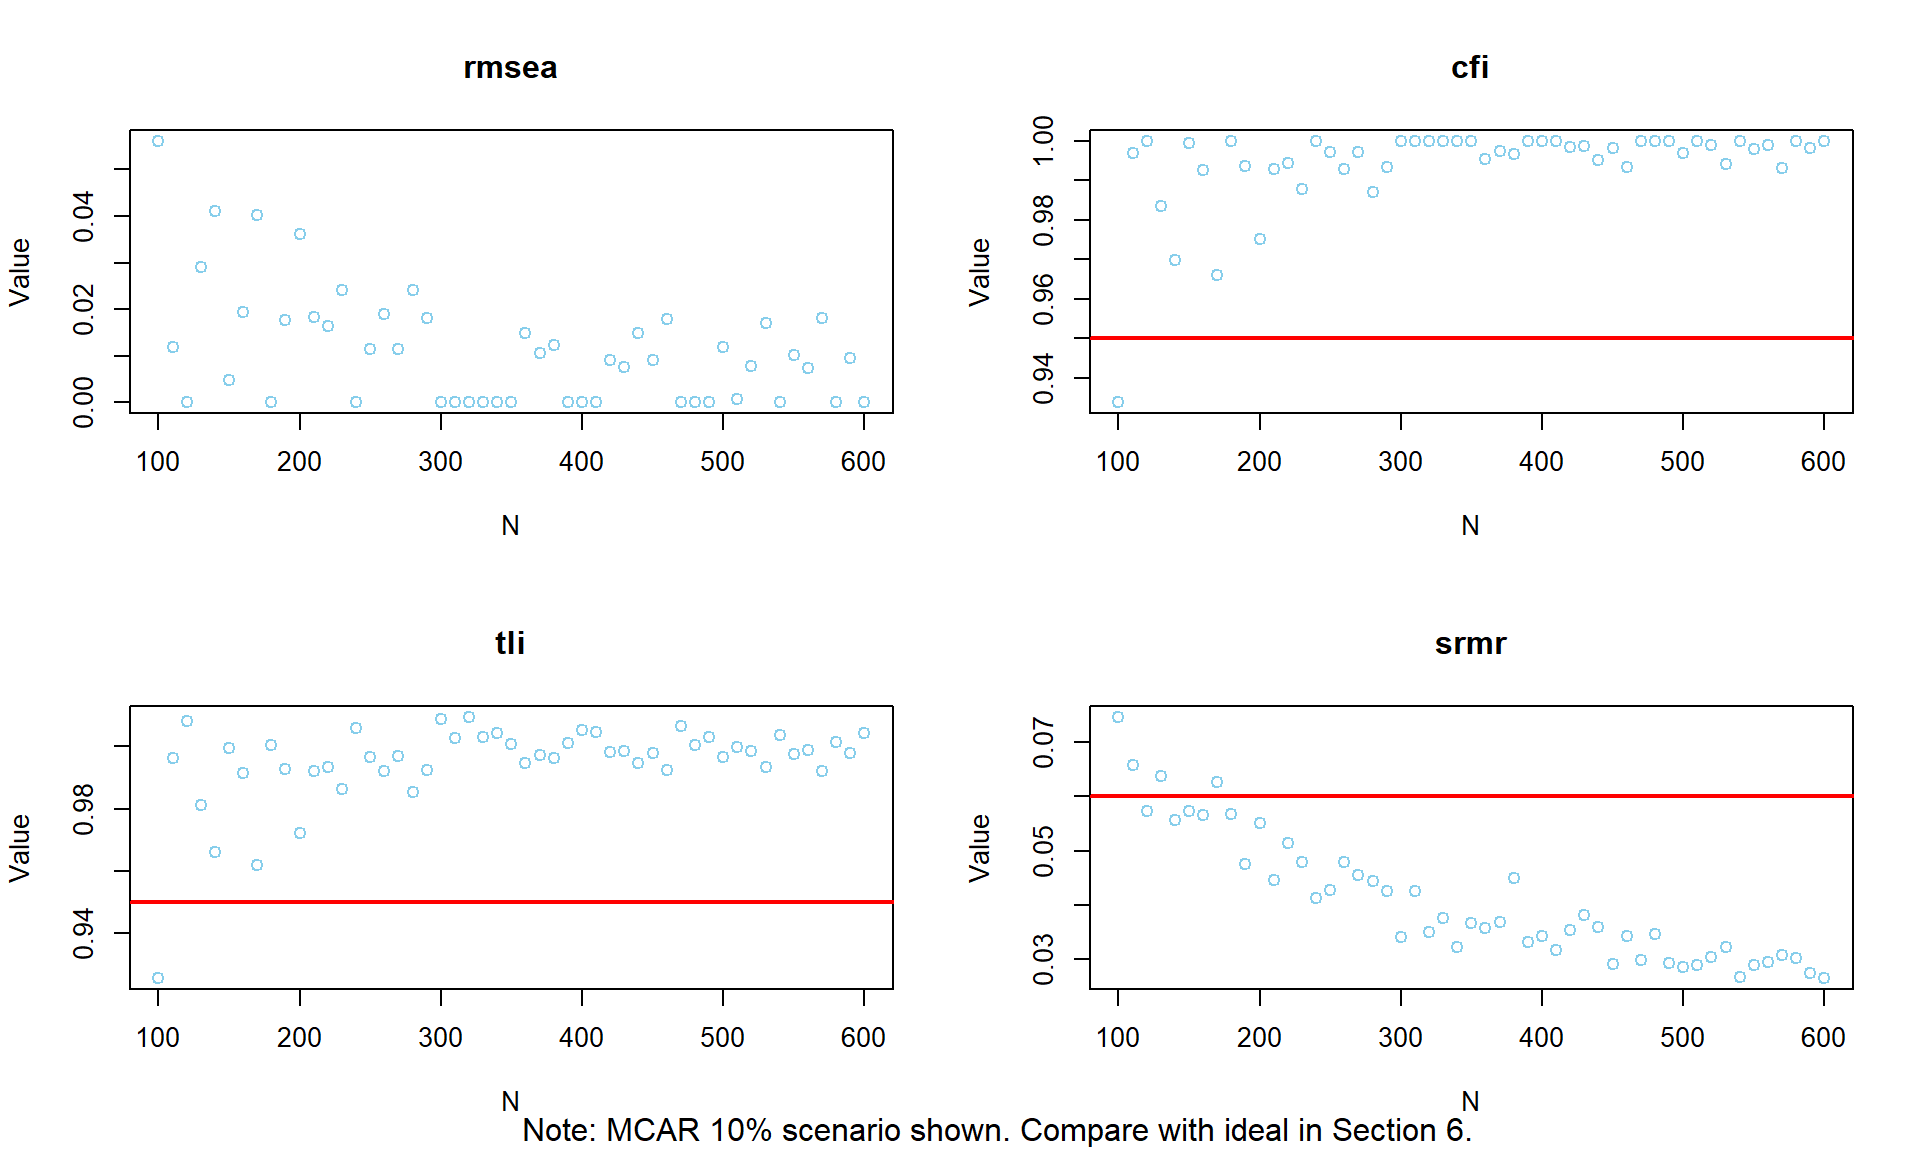

In [ ]:

# Overlay power-fit plots for the three population models
# Using the SRMR < .06 cutoff as the reference
par(mfrow = c(1, 1))
plotPowerFit(sim_missing_vary, cutoff = RULE_OF_THUMB, logistic = FALSE)
title(sub = "Note: MCAR 10% scenario shown. Compare with ideal in Section 6.")


## Summary: N requirements across all scenarios

In [ ]:

# Note: Values below are placeholders — replace with actual findPower() results
n_requirements <- data.frame(
  Scenario = c(
    "Analytical (semPower, RMSEA ≥ .05)",
    "Simulation — Ideal (popModel, ML)",
    "Simulation — Missing data (popModel, 10% MCAR)",
    "Simulation — Naive model (loadings = .5)",
    "Simulation — Optimistic model (loadings = .7)"
  ),
  `Approach` = c(
    "Analytical",
    "Monte Carlo",
    "Monte Carlo",
    "Monte Carlo",
    "Monte Carlo"
  ),
  `N for 80% Power` = c(
    "See @sec-apriori",
    "From Section 6",
    "From sim-missing above",
    "From sim-naive above",
    "From sim-opt above"
  ),
  `Key Assumption` = c(
    "Continuous, normal, ML",
    "Continuous, normal, ML",
    "Continuous, normal, ML + 10% MCAR",
    "Weak loadings (0.5)",
    "Strong loadings (0.7), mod. correlations (0.5)"
  ),
  check.names = FALSE
)

kable(n_requirements, align = "llll")


  -------------------------------------------------------------------------------
  Scenario                  Approach     N for 80%      Key Assumption
                                         Power          
  ------------------------- ------------ -------------- -------------------------
  Analytical (semPower,     Analytical   See            Continuous, normal, ML
  RMSEA ≥ .05)                           @sec-apriori   

  Simulation --- Ideal      Monte Carlo  From Section 6 Continuous, normal, ML
  (popModel, ML)                                        

  Simulation --- Missing    Monte Carlo  From           Continuous, normal, ML +
  data (popModel, 10% MCAR)              sim-missing    10% MCAR
                                         above          

  Simulation --- Naive      Monte Carlo  From sim-naive Weak loadings (0.5)
  model (loadings = .5)                  above          

  Simulation --- Optimistic Monte Carlo  From sim-opt   Strong loadings (0.7),
  model (loadings = .7)                  above          mod. correlations (0.5)
  -------------------------------------------------------------------------------
